# Lexicon-Based Sentiment Analysis

**Notebook 1 of 4** — LA Reddit Community Analysis, GBA 6410 Group 7

This notebook covers the first two phases of the sentiment analysis workflow:

- **Phase 1** — prepare a text representation suited to sentiment scoring, and draw a verification sample
- **Phase 2** — score the full corpus with TextBlob and VADER, and characterise how each behaves on this data

**Input:** the final cleaned comments dataset (498,147 records)
**Outputs:** lexicon scores for the full corpus and for the sample, both keyed on `comment_id`

Runs on CPU. The transformer models are scored in notebooks 2 and 2b, which require a GPU runtime.

Design decisions and their justifications are documented in the accompanying process documentation; the notes here explain what each cell does and why it is written the way it is.

---
# Phase 1 — Preparing Text for Sentiment Scoring

## Setup

Google Drive holds both the input data and every output, so that nothing is lost when a Colab session ends. Colab already provides pandas, numpy, matplotlib, seaborn, pyarrow, and tqdm; only the two sentiment libraries need installing. TextBlob ships without its linguistic data, so its corpora are downloaded separately.

In [2]:
# Mount Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Colab ships pandas, numpy, matplotlib, seaborn, pyarrow, tqdm.
# Only the sentiment libraries are missing.

!pip install -q textblob vaderSentiment
!python -m textblob.download_corpora

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.0 MB/s eta 0:00:00
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.


## Configuration

Every constant that affects results is defined in one place so that a reader can see all of them at once. The same block appears at the top of each notebook in the series.

The fingerprint at the end is a hash of the analysis constants. Notebooks 2, 2b, and 3 assert the same value, which catches the case where one copy of the config is edited and the others are not. Without it, a changed seed or sample size would silently cause one notebook to work on a different set of records than another, and nothing would raise an error.

In [4]:
# ==================================================================
#  SHARED CONFIG — identical in every notebook in this series.
#  Edit here, then copy this whole cell to notebooks 02, 02b, and 03.
#  CONFIG_FINGERPRINT below catches a stale copy.
# ==================================================================
import re, html, hashlib, unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# --- Analysis constants -------------------------------------------
RANDOM_SEED    = 42
SAMPLE_N       = 100_000
POS_T, NEG_T   = 0.05, -0.05    # lexicon class thresholds
CONF_THRESHOLD = 0.50           # topic assignment confidence cut

# --- Corpus facts (verified against the preprocessing output) ------
EXPECTED_ROWS = 498_147
EXPECTED_COLS = 13

# --- Paths --------------------------------------------------------
BASE = Path("/content/drive/MyDrive/GBA6410")
BASE.mkdir(parents=True, exist_ok=True)

PATHS = {
    # inputs
    "raw":          BASE / "comments_clean_final.csv",
    "topics":       BASE / "topic_assignments.parquet",
    # notebook 01 outputs
    "sample":       BASE / "sample_100k_stage1.parquet",
    "scored":       BASE / "corpus_scored_lexicon.parquet",
    "lex_full":     BASE / "lexicon_scores_full.parquet",
    "lex_sample":   BASE / "lexicon_scores_sample.parquet",
    # notebook 02 outputs
    "transformer":  BASE / "transformer_scores.parquet",
}

# --- Drift guard --------------------------------------------------
# Any change to a constant above changes this hash. The other notebooks
# assert the same value, so a stale copy of this cell fails loudly
# instead of silently working on a different set of records.
CONFIG_FINGERPRINT = hashlib.md5(
    f"{RANDOM_SEED}|{SAMPLE_N}|{POS_T}|{NEG_T}|{CONF_THRESHOLD}".encode()
).hexdigest()[:8]

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_colwidth", 150)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

print(f"Config fingerprint: {CONFIG_FINGERPRINT}")
print(f"Base: {BASE}")

Config fingerprint: ae74dc34
Base: /content/drive/MyDrive/GBA6410


## Preflight checks

Three conditions are verified before any expensive work begins: the runtime type is appropriate, the required input files exist, and Drive can be written to. The last matters most — a full or read-only mount would otherwise surface only at the point of saving, after the scoring run has already completed.

In [7]:
# ---- 1. Runtime type ---------------------------------------------
import subprocess
gpu = subprocess.run("nvidia-smi", shell=True, capture_output=True).returncode == 0
if gpu:
    print("NOTE: GPU runtime active. Phases 1-2 are CPU-only — consider "
          "switching to CPU (Runtime > Change runtime type) to preserve "
          "GPU quota for notebook 02.")
else:
    print("OK: CPU runtime (correct for this notebook).")

# ---- 2. Required inputs present ----------------------------------
for key in ["raw", "topics"]:
    p = PATHS[key]
    assert p.exists(), (
        f"Missing input '{key}': {p}\n"
        f"Upload it to Drive at {BASE} before continuing."
    )
    print(f"OK: {key:8s} {p.stat().st_size / 1e6:8.1f} MB")

# ---- 3. Drive is writable ----------------------------------------
# Fail now, not after a 25-minute scoring run.
_probe = BASE / ".write_test"
_probe.write_text("ok")
assert _probe.read_text() == "ok", "Cannot write to Drive"
_probe.unlink()
print("OK: Drive writable")

OK: CPU runtime (correct for this notebook).
OK: raw         335.0 MB
OK: topics        8.1 MB
OK: Drive writable


## Checkpoint resume

Scoring the full corpus takes roughly half an hour, most of it in a single cell. If a session disconnects afterwards, re-running from the top would repeat that work unnecessarily. This cell detects a completed scoring run on disk and loads it, allowing the expensive cells to be skipped.

In [9]:
# ---- Checkpoint resume -------------------------------------------
# Scoring writes a checkpoint. If it exists, reload it and skip the
# load / clean / score cells below.

if PATHS["scored"].exists():
    df = pd.read_parquet(PATHS["scored"])
    print(f"RESUMED from checkpoint: {len(df):,} rows x {df.shape[1]} cols")
    print("Scoring already complete — continue from the labelling step.")
    RESUMED = True
else:
    print("No checkpoint found. Run the load, clean, sample, and score cells.")
    RESUMED = False

No checkpoint found. Run cells 5-8 (load, clean, sample, score).


## Loading the corpus

Three details in this cell are worth noting.

The file was saved with a byte-order mark for Excel compatibility, so it is read with `utf-8-sig`. Reading it as plain UTF-8 would attach an invisible character to the first column name, causing lookups on that column to fail while the name still prints normally.

Identifier columns are typed explicitly as strings. Reddit identifiers can look numeric, and an identifier cast to an integer would break every downstream join between this notebook's output and the others.

The timestamp format is passed explicitly rather than inferred, which is both faster across half a million rows and avoids inconsistent parsing.

The assertions check record count, key uniqueness, and the presence of every column the workflow depends on. Key uniqueness matters in particular because every phase handoff joins on `comment_id`; a duplicate would silently multiply rows.

In [10]:
# Load with shape assertions

if not RESUMED:
    df = pd.read_csv(
        PATHS["raw"],
        encoding="utf-8-sig",
        dtype={"post_id": "string", "comment_id": "string",
               "parent_id": "string", "author": "string"},
    )

    df["created_dt"] = pd.to_datetime(
        df["created_utc"].str.replace(" UTC", "", regex=False),
        format="%Y-%m-%d %H:%M:%S", utc=True,
    )

    # ---- shape and key integrity ----
    assert len(df) == EXPECTED_ROWS, f"Expected {EXPECTED_ROWS:,}, got {len(df):,}"
    assert df["comment_id"].notna().all(), "Null comment_id present"
    assert not df["comment_id"].duplicated().any(), "Duplicate comment_id present"

    required = {"body", "clean_body_stop", "clean_body_nostop",
                "comment_id", "parent_id", "created_utc", "word_count"}
    missing = required - set(df.columns)
    assert not missing, f"Missing required columns: {missing}"

    print(f"OK: {len(df):,} rows x {df.shape[1]} cols, keys unique")
    print("Date range:", df["created_dt"].min(), "→", df["created_dt"].max())
    print("\nNull counts:")
    print(df.isna().sum()[lambda s: s > 0])

OK: 498,147 rows x 14 cols, keys unique
Date range: 2025-08-28 03:40:05+00:00 → 2026-06-24 03:55:36+00:00

Null counts:
post_title    1663
dtype: int64


## Deriving the sentiment text column

The preprocessing pipeline produced two cleaned columns, both lowercased and with emoji removed. Those steps suit term-frequency methods but discard information the sentiment methods use directly: VADER treats capitalisation as an intensity modifier and carries emoji entries in its dictionary, and transformer tokenizers represent both as meaningful input.

A third column is therefore derived from the original comment text, applying every cleaning step from the original pipeline except lowercasing and emoji removal.

Two properties of this step are deliberate.

**Operation order.** Markdown links are unwrapped before URLs are stripped. Reversing the two would remove the URL first, leaving orphaned bracket text that the link pattern no longer matches. The single-underscore pattern is also excluded from markdown stripping, because Reddit usernames contain underscores.

**No records are removed.** All deduplication, length filtering, and language filtering during preprocessing was decided against the cleaned column, and these 498,147 records are the survivors of that process. Re-deriving the corpus from raw text and re-filtering would produce a different record set, breaking alignment with every other column and invalidating the preprocessing documentation. Adding a column preserves that alignment.

In [11]:
URL_RE      = re.compile(r"https?://\S+|www\.\S+")
MD_LINK_RE  = re.compile(r"\[([^\]]+)\]\([^)]*\)")
MD_MARKS_RE = re.compile(r"\*\*|\*|~~|`|__")
QUOTE_RE    = re.compile(r"^\s*>+\s?", flags=re.MULTILINE)
HEADER_RE   = re.compile(r"^\s*#{1,6}\s*", flags=re.MULTILINE)
CTRL_RE     = re.compile(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f\ufffd]")
WS_RE       = re.compile(r"\s+")

def clean_for_sentiment(text):
    """Stage 1 cleaning MINUS lowercasing and emoji removal.

    Case and emoji are intensity signals VADER uses and the transformers
    tokenize meaningfully. Everything else — URLs, markdown, HTML
    entities, control chars — is noise, removed as in the original
    pipeline so this column stays comparable to clean_body_stop.
    """
    if not isinstance(text, str):
        return ""

    t = unicodedata.normalize("NFKC", text)
    t = t.replace("\u2019", "'").replace("\u2018", "'")  # curly → straight
    t = QUOTE_RE.sub("", t)          # Reddit quote markers ">"
    t = HEADER_RE.sub("", t)         # markdown headers
    t = MD_LINK_RE.sub(r"\1", t)     # [text](url) → text
    t = URL_RE.sub(" ", t)
    t = html.unescape(t)             # &amp; → &
    t = MD_MARKS_RE.sub("", t)       # **bold**, *italic*, ~~strike~~
    t = CTRL_RE.sub("", t)
    t = t.replace("\u00a0", " ").replace("\u200b", "").replace("\u200d", "")

    return WS_RE.sub(" ", t).strip()


df["sent_text"] = df["body"].apply(clean_for_sentiment)
print("Empty after cleaning:", (df["sent_text"].str.len() == 0).sum())

Empty after cleaning: 0


## Measuring whether the change matters

Rather than asserting that preserving capitalisation and emoji is worthwhile, the difference between the two columns is measured directly.

The result confirmed that punctuation had never been stripped — exclamation marks appear at identical rates in both columns — so the difference is confined to capitalisation and emoji. That is a narrower gap than initially assumed, and it is the reason the effect is measured on each method later rather than taken for granted.

In [12]:
emoji_re = re.compile("[\U0001F300-\U0001FAFF\U00002600-\U000027BF]")
caps_re  = re.compile(r"\b[A-Z]{3,}\b")

checks = pd.DataFrame({
    "sent_text (new)": [
        df["sent_text"].str.contains(emoji_re).mean(),
        df["sent_text"].str.contains(caps_re).mean(),
        df["sent_text"].str.contains("!").mean(),
    ],
    "clean_body_stop (old)": [
        df["clean_body_stop"].str.contains(emoji_re).mean(),
        df["clean_body_stop"].str.contains(caps_re).mean(),
        df["clean_body_stop"].str.contains("!").mean(),
    ],
}, index=["has emoji", "has ALLCAPS word", "has !"])

print("% of rows:")
print((checks * 100).round(2), "\n")

for i in df.index[df["sent_text"].str.contains(caps_re)][:3]:
    print("NEW:", df.at[i, "sent_text"][:110])
    print("OLD:", df.at[i, "clean_body_stop"][:110], "\n")

% of rows:
                  sent_text (new)  clean_body_stop (old)
has emoji                    3.33                   0.00
has ALLCAPS word            13.33                   0.00
has !                        8.63                   8.63 

NEW: Actually WMT closed a few stores the same day including Baldwin Hills and Pico Rivera (though it reopened). Th
OLD: actually wmt closed a few stores the same day including baldwin hills and pico rivera (though it reopened). th 

NEW: werent all those crown buses and trucks built in LA? I know Crown made those sooty old buses but they made fir
OLD: werent all those crown buses and trucks built in la? i know crown made those sooty old buses but they made fir 

NEW: Dems can vote in Repub primaries for legislative races, but not presidential primaries. State GOP keeps the pr
OLD: dems can vote in repub primaries for legislative races, but not presidential primaries. state gop keeps the pr 



## Drawing the verification sample

A random sample of 100,000 records is drawn with a fixed seed. The sample originally existed because transformer scoring over the full corpus was expected to be impractical; that expectation proved wrong, and all four methods were eventually run over all 498,147 records. The sample is retained because comparing sample results against full-corpus results provides direct evidence that the sampling approach was sound.

Representativeness is verified on length distribution and thread position — the two properties most likely to correlate with sentiment behaviour. The topic coverage check confirms the sample joins cleanly to the topic assignments before anything is built on top of that join.

Parquet is used rather than CSV because it preserves column types: string columns return as strings and the timestamp returns as a timestamp, rather than everything reverting to text.

In [13]:
sample = (df.sample(n=SAMPLE_N, random_state=RANDOM_SEED)
            .copy().reset_index(drop=True))

print(f"Sample: {len(sample):,} of {len(df):,} ({len(sample)/len(df):.1%})\n")

print("Word count — full vs sample:")
print(pd.DataFrame({"full":   df["word_count"].describe(),
                    "sample": sample["word_count"].describe()}).round(1))

print("\nTop-level (t3_) share — "
      f"full: {df['parent_id'].str.startswith('t3_').mean():.1%} | "
      f"sample: {sample['parent_id'].str.startswith('t3_').mean():.1%}")

# --- confirm every sampled comment has a topic (Phase 7 dependency) ---
topics = pd.read_parquet(PATHS["topics"])
covered = sample["comment_id"].isin(set(topics["comment_id"])).mean()
print(f"\nTopic coverage of sample: {covered:.2%}   (expect 100.00%)")

hi_conf = topics.set_index("comment_id")["topic_prob"].reindex(sample["comment_id"])
print(f"Sample rows with topic_prob >= 0.50: {(hi_conf >= 0.50).mean():.1%}")

sample.to_parquet(PATHS["sample"], index=False)

Sample: 100,000 of 498,147 (20.1%)

Word count — full vs sample:
           full    sample
count  498147.0  100000.0
mean       29.9      30.0
std        37.8      37.5
min         3.0       3.0
25%        10.0      10.0
50%        19.0      19.0
75%        35.0      35.0
max      1588.0    1068.0

Top-level (t3_) share — full: 34.3% | sample: 34.5%

Topic coverage of sample: 100.00%   (expect 100.00%)
Sample rows with topic_prob >= 0.50: 45.1%


---
# Phase 2 — Lexicon-Based Sentiment

## How the two methods work

Understanding the mechanism explains the failure modes observed later.

**TextBlob** looks up each word in a hand-built dictionary where entries carry a polarity from −1 to +1 and a subjectivity from 0 to 1, then averages across the words it matched. Words absent from the dictionary contribute nothing. Its polarity score therefore means "how positive were the sentiment words recognised," and subjectivity means "how opinionated rather than factual."

**VADER** performs the same lookup and adds rules on top: negation flips nearby scores, intensifiers scale them, capitalisation and exclamation marks amplify, and the dictionary includes emoji and slang. Its compound score is the rule-adjusted sum, normalised to the range −1 to +1.

The shared limitation follows from the mechanism. Neither method has any representation of context; both operate word by word. A sarcastic comment such as "Oh great, another pothole" contains only one sentiment word, and both methods score it positive. This is not a tuning problem — it is what a lexicon is.

## Scoring functions

**Why the thresholding is a named function.** Both lexicon methods return a continuous score, but the deliverable requires three classes, so cut-points must be chosen. This is a methodological decision rather than an implementation detail, and making it an explicit parameterised function keeps it visible and makes the sensitivity analysis below trivial to write. The transformer models in later notebooks do not need this step, as they emit classes directly.

**Why a loop rather than `.apply()`.** A common pattern returns a pandas Series from each row, which allocates one Series object per record — half a million of them at this scale. Plain lists with a single array assignment at the end is faster and provides a progress bar, which matters for a cell that runs twenty minutes.

In [14]:
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

# Symmetric class thresholds. +/-0.05 is the convention recommended by
# VADER's authors. TextBlob has no standard convention, so the same
# value is used to keep the two methods directly comparable. Because
# the TextBlob value is arbitrary, its influence is tested below.
POS_T, NEG_T = 0.05, -0.05

def label_from_score(s, pos_t=POS_T, neg_t=NEG_T):
    """Continuous score -> three-class label."""
    if s >= pos_t:
        return "positive"
    if s <= neg_t:
        return "negative"
    return "neutral"

def score_textblob(texts, desc="TextBlob"):
    """Returns (polarity, subjectivity) arrays aligned to input order."""
    pol, subj = [], []
    for t in tqdm(texts, desc=desc, unit="doc", miniters=5000):
        s = TextBlob(t).sentiment
        pol.append(s.polarity)
        subj.append(s.subjectivity)
    return np.asarray(pol), np.asarray(subj)

def score_vader(texts, desc="VADER"):
    """Returns (neg, neu, pos, compound) arrays aligned to input order."""
    neg, neu, pos, comp = [], [], [], []
    for t in tqdm(texts, desc=desc, unit="doc", miniters=5000):
        d = sia.polarity_scores(t)
        neg.append(d["neg"]); neu.append(d["neu"])
        pos.append(d["pos"]); comp.append(d["compound"])
    return (np.asarray(neg), np.asarray(neu),
            np.asarray(pos), np.asarray(comp))

## Scoring the full corpus

Both methods run over all 498,147 records. TextBlob takes considerably longer than VADER because it runs a part-of-speech tagger internally — it needs to know whether a word like "fine" is functioning as an adjective or a noun — while VADER is dictionary lookups and arithmetic.

The result is checkpointed immediately. This is the most expensive cell in the notebook, and a session disconnect afterwards should not require repeating it.

In [15]:
texts = df["sent_text"].tolist()   # materialize once; faster than .iloc per row

tb_pol, tb_subj = score_textblob(texts)
v_neg, v_neu, v_pos, v_comp = score_vader(texts)

df["tb_polarity"]     = tb_pol
df["tb_subjectivity"] = tb_subj
df["vader_neg"]       = v_neg
df["vader_neu"]       = v_neu
df["vader_pos"]       = v_pos
df["vader_compound"]  = v_comp

# checkpoint immediately — this cell is the expensive one
df.to_parquet(PATHS["scored"], index=False)
print("Scored and checkpointed:", f"{len(df):,}")

TextBlob:   0%|          | 0/498147 [00:00<?, ?doc/s]

VADER:   0%|          | 0/498147 [00:00<?, ?doc/s]

Scored and checkpointed: 498,147


## Class labels and the abstention check

Both methods return a score of exactly zero when no word in the text appears in their dictionary. That outcome is the method reporting that it has nothing to work with — but it lands in the neutral class, indistinguishable from a genuine judgment that a comment is balanced.

Exact-zero counts are therefore recorded as a separate flag. The second figure printed for each method is the important one: the proportion of its neutral class that consists of these non-answers.

In [16]:
df["tb_label"]    = [label_from_score(p) for p in df["tb_polarity"]]
df["vader_label"] = [label_from_score(c) for c in df["vader_compound"]]

# Exact zero = no lexicon match = abstention, NOT a judgment of neutrality
df["tb_is_zero"]    = df["tb_polarity"].eq(0.0)
df["vader_is_zero"] = df["vader_compound"].eq(0.0)

summary = pd.DataFrame({
    "TextBlob": df["tb_label"].value_counts(normalize=True),
    "VADER":    df["vader_label"].value_counts(normalize=True),
}).reindex(["positive", "neutral", "negative"]).fillna(0)

print("Label shares (%):")
print((summary * 100).round(2), "\n")

for name, zcol, lcol in [("TextBlob", "tb_is_zero", "tb_label"),
                         ("VADER", "vader_is_zero", "vader_label")]:
    print(f"{name}: exact-zero {df[zcol].mean():.1%} of all rows | "
          f"{df.loc[df[lcol]=='neutral', zcol].mean():.1%} of its neutral class")

Label shares (%):
          TextBlob  VADER
positive     42.76  42.28
neutral      34.50  22.72
negative     22.74  35.00 

TextBlob: exact-zero 26.0% of all rows | 75.4% of its neutral class
VADER: exact-zero 21.0% of all rows | 92.6% of its neutral class


**Result.** The abstention rates are high enough to change how the neutral class should be read. 75.4% of TextBlob's neutral labels and 92.6% of VADER's are exact-zero scores. Removing them leaves genuine neutral judgments at 8.5% of the corpus for TextBlob and 1.7% for VADER.

VADER is therefore effectively a two-class method with a large bin of unprocessed text attached. This becomes significant later: the human-coded benchmark puts genuine neutral content at 37% of the corpus, which neither lexicon method is capable of identifying.

## Score and label distributions

`.reindex()` forces a consistent class order across all four panels. Without it, pandas orders by frequency and the bars move between plots, making visual comparison misleading.

The spike at exactly zero in both histograms is the abstention mass from the previous cell, shown visually.

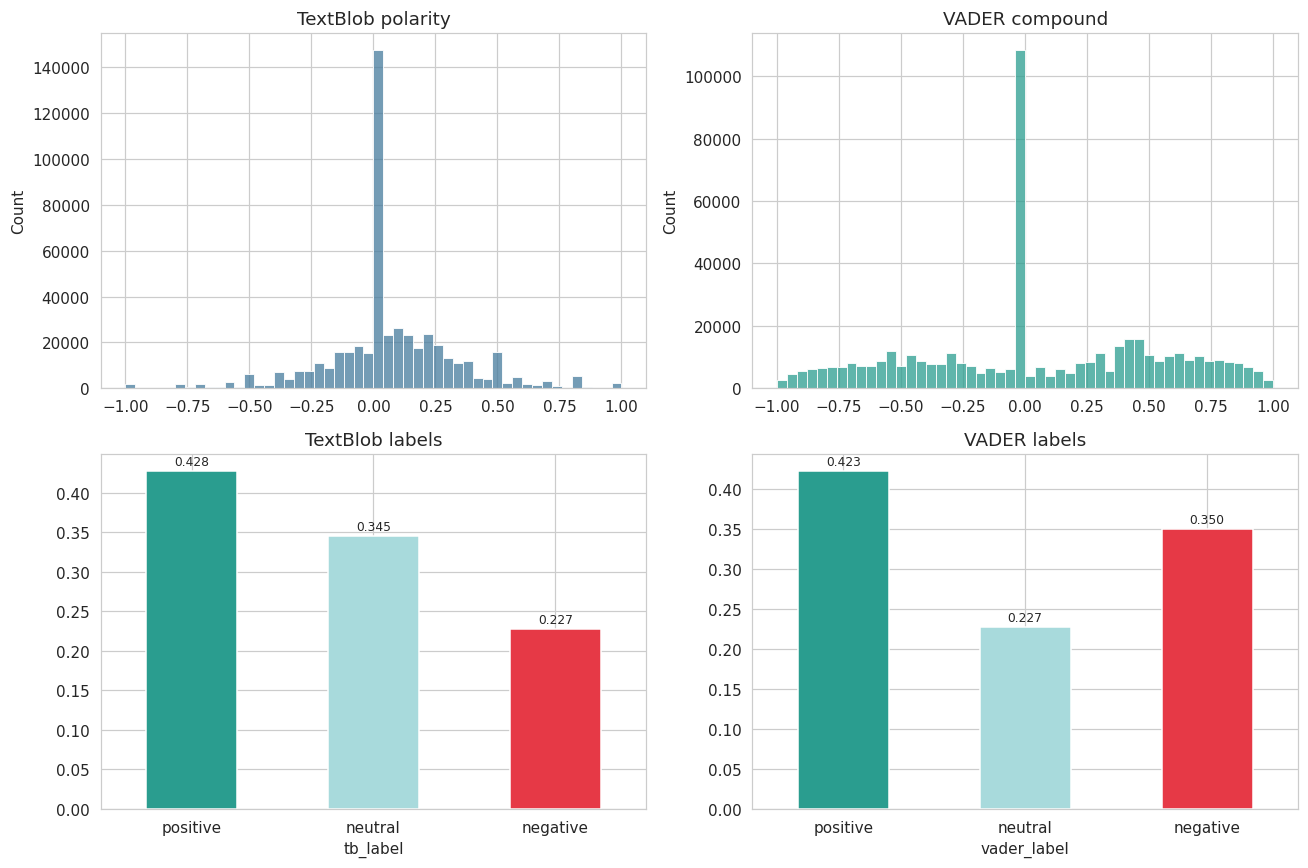

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df["tb_polarity"], bins=50, ax=axes[0, 0], color="#457B9D")
axes[0, 0].set_title("TextBlob polarity"); axes[0, 0].set_xlabel("")

sns.histplot(df["vader_compound"], bins=50, ax=axes[0, 1], color="#2A9D8F")
axes[0, 1].set_title("VADER compound"); axes[0, 1].set_xlabel("")

for ax, col, title in [(axes[1, 0], "tb_label", "TextBlob labels"),
                       (axes[1, 1], "vader_label", "VADER labels")]:
    (df[col].value_counts(normalize=True)
            .reindex(["positive", "neutral", "negative"])
            .plot(kind="bar", ax=ax, color=["#2A9D8F", "#A8DADC", "#E63946"]))
    ax.set_title(title); ax.tick_params(axis="x", rotation=0)
    ax.bar_label(ax.containers[0], fmt="%.3f", padding=2, fontsize=8)

plt.tight_layout(); plt.show()

## Agreement between the two methods

A single agreement percentage hides the structure of the disagreement. The crosstab shows where the two methods diverge, and row-normalising answers a more specific question: of everything TextBlob labelled negative, what did VADER label it? That is more informative than raw counts when classes are imbalanced.

In [18]:
agree = (df["tb_label"] == df["vader_label"]).mean()
print(f"TextBlob and VADER agree on {agree:.1%} of comments\n")

ct = pd.crosstab(df["tb_label"], df["vader_label"],
                 rownames=["TextBlob"], colnames=["VADER"])
print(ct, "\n")
print("Row-normalized (%) — how TextBlob's classes map onto VADER's:")
print((ct.div(ct.sum(axis=1), axis=0) * 100).round(1))

TextBlob and VADER agree on 55.9% of comments

VADER     negative  neutral  positive
TextBlob                             
negative     73309    16723     23233
neutral      53588    67917     50357
positive     47434    28542    137044 

Row-normalized (%) — how TextBlob's classes map onto VADER's:
VADER     negative  neutral  positive
TextBlob                             
negative      64.7     14.8      20.5
neutral       31.2     39.5      29.3
positive      22.3     13.4      64.3


**Result.** The two methods agree on 55.9% of comments. The structure matters more than the headline: TextBlob's neutral row splits almost evenly across VADER's three classes (31.2 / 39.5 / 29.3), meaning that for roughly a third of the corpus, one method's label carries almost no information about the other's. That follows directly from the abstention finding — most of that row is TextBlob declining to answer.

70,667 comments, 14.2% of the corpus, receive directly opposite labels from the two methods.

## Threshold sensitivity

The ±0.05 cut-point has published backing for VADER but is arbitrary for TextBlob. Rather than leaving that unexamined, the same labelling is repeated at wider cut-points to show how much the reported distribution depends on the choice.

The question being asked is whether the *ordering* of classes holds throughout. If it does, the qualitative conclusion is robust to a decision that cannot be fully justified.

`shares.get("positive", 0)` is used rather than direct indexing because a class can disappear entirely at a wide threshold, and indexing a missing key would raise.

In [19]:
rows = []
for t in [0.05, 0.10, 0.20]:
    for name, col in [("TextBlob", "tb_polarity"), ("VADER", "vader_compound")]:
        lab = pd.Series([label_from_score(s, t, -t) for s in df[col]])
        shares = lab.value_counts(normalize=True)
        rows.append({"method": name, "threshold": f"±{t}",
                     "positive": shares.get("positive", 0),
                     "neutral":  shares.get("neutral", 0),
                     "negative": shares.get("negative", 0)})

print((pd.DataFrame(rows).set_index(["method", "threshold"]) * 100).round(1))

                    positive  neutral  negative
method   threshold                             
TextBlob ±0.05          42.8     34.5      22.7
VADER    ±0.05          42.3     22.7      35.0
TextBlob ±0.1           37.0     44.5      18.5
VADER    ±0.1           40.8     25.6      33.6
TextBlob ±0.2           25.4     63.1      11.5
VADER    ±0.2           37.9     31.6      30.5


**Result.** The two methods respond very differently. TextBlob's neutral share nearly doubles across the range tested, from 34.5% to 63.1%, while VADER's moves by nine points. TextBlob's scores cluster tightly around zero, so a large share of the corpus falls inside any moderately wide neutral band.

This is an argument for preferring VADER that is independent of accuracy: TextBlob's distribution is substantially an artifact of a cut-point with no principled basis, and VADER's is not.

One conclusion survives at every threshold for both methods: positive exceeds negative. That much is robust; the size of the neutral class is not.

## Effect of preserving capitalisation and emoji

A controlled comparison: the same records, the same methods, and the same thresholds, with only the input text differing. That isolation is what makes any difference attributable to the text representation rather than to something else.

The comparison runs on the 100,000-record sample rather than the full corpus. The effect size does not require half a million records to estimate, and this avoids a second twenty-minute scoring pass.

The crosstab is more informative than the change rate, because it shows the direction of movement.

In [20]:
sample_ids = set(pd.read_parquet(PATHS["sample"],
                                 columns=["comment_id"])["comment_id"])
m = df["comment_id"].isin(sample_ids)

sub = df.loc[m, ["comment_id", "clean_body_stop",
                 "tb_label", "vader_label"]].copy()

# Re-score the SAME rows using the OLD cleaned column
old_texts = sub["clean_body_stop"].fillna("").tolist()
old_tb_pol, _ = score_textblob(old_texts, desc="TextBlob (old col)")
*_, old_comp  = score_vader(old_texts, desc="VADER (old col)")

sub["tb_label_old"]    = [label_from_score(p) for p in old_tb_pol]
sub["vader_label_old"] = [label_from_score(c) for c in old_comp]

for name in ["tb", "vader"]:
    changed = sub[f"{name}_label"] != sub[f"{name}_label_old"]
    print(f"{name}: {changed.mean():.2%} of labels differ "
          f"({changed.sum():,} of {len(sub):,})")
    if changed.any():
        print(pd.crosstab(sub.loc[changed, f"{name}_label_old"],
                          sub.loc[changed, f"{name}_label"],
                          rownames=["old"], colnames=["new"]), "\n")

TextBlob (old col):   0%|          | 0/100000 [00:00<?, ?doc/s]

VADER (old col):   0%|          | 0/100000 [00:00<?, ?doc/s]

tb: 0.04% of labels differ (40 of 100,000)
new       negative  neutral  positive
old                                  
negative         0        7         1
neutral          5        0         8
positive         4       15         0 

vader: 0.80% of labels differ (801 of 100,000)
new       negative  neutral  positive
old                                  
negative         0       46       212
neutral        132        0       284
positive        99       28         0 



**Result.** TextBlob changes on 0.04% of labels and VADER on 0.80% — a twenty-fold difference, in the direction the mechanism predicts, since VADER has rules for capitalisation and emoji and TextBlob has none. TextBlob's forty changed labels are almost certainly attributable to other differences between the two text versions rather than to capitalisation or emoji at all.

VADER's direction is also informative: 496 comments moved toward positive against 231 toward negative, consistent with emoji in VADER's dictionary skewing positive.

On this evidence alone the effect looked small. The same comparison run against the selected transformer model in notebook 2 gave 5.08%, which is why the decision is documented as a substantive methodological point rather than a footnote.

## Stress test

Eight hand-written cases, each probing one mechanism: negation, capitalised emphasis, slang, sarcasm, genuine neutrality, and emoji-carried sentiment. The final three use local subject matter so that the documented failure modes reflect the domain under study.

The value here is diagnostic rather than statistical. These cases demonstrate a mechanism concretely; they do not estimate a rate.

In [21]:
stress = [
    "The apartment was not bad at all, actually really nice.",    # negation
    "This place was GREAT!!! Would stay again in a heartbeat.",   # caps + punct
    "The AC was sick, best stay ever.",                           # slang
    "Oh great, another pothole on my street.",                     # sarcasm
    "It was fine, nothing special but nothing wrong either.",      # true neutral
    "traffic on the 405 was moving fine today",                    # local, neutral
    "LAPD response time was unacceptable",                         # domain negative
    "rent went up again 🙃",                                       # emoji-carried
]

pd.DataFrame([{
    "text": t,
    "TextBlob": round(TextBlob(t).sentiment.polarity, 3),
    "VADER":    round(sia.polarity_scores(t)["compound"], 3),
} for t in stress])

,text,TextBlob,VADER
0,"The apartment was not bad at all, actually really nice.",0.475,0.713
1,This place was GREAT!!! Would stay again in a heartbeat.,1.000,0.772
2,"The AC was sick, best stay ever.",0.143,0.226
3,"Oh great, another pothole on my street.",0.800,0.625
4,"It was fine, nothing special but nothing wrong either.",0.091,0.477
5,traffic on the 405 was moving fine today,0.417,0.202
6,LAPD response time was unacceptable,0.000,-0.459
7,rent went up again 🙃,0.000,0.000


**What to look for.** VADER should outperform TextBlob on the negation and capitalisation cases, since it has rules for both and TextBlob has neither. Both should fail on the sarcasm case, which requires context neither method represents. The final case tests emoji directly: a non-zero VADER score confirms that preserving emoji contributed signal, since the same comment scored on the standard cleaned column would return exactly zero.

## Saving

Scores are saved keyed on `comment_id` rather than as a whole dataframe, so that the next phase joins on a key rather than trusting row order. Row-order dependencies are fragile: a single stray sort would attach every sentiment score to the wrong comment, and nothing in the output would look wrong. Two extra columns avoid an entire class of silent error.

Both a full-corpus and a sample-scoped copy are written. The sample copy supports the sample-versus-full comparison used to validate the sampling design.

In [22]:
lex_cols = ["comment_id", "tb_polarity", "tb_subjectivity", "tb_label",
            "tb_is_zero", "vader_neg", "vader_neu", "vader_pos",
            "vader_compound", "vader_label", "vader_is_zero"]

df[lex_cols].to_parquet(PATHS["lex_full"], index=False)
df.loc[m, lex_cols].to_parquet(PATHS["lex_sample"], index=False)
print("Saved. Full:", f"{len(df):,}", "| Sample:", f"{m.sum():,}")

Saved. Full: 498,147 | Sample: 100,000


---
## Outputs

| File | Contents |
|---|---|
| `corpus_scored_lexicon.parquet` | Full corpus with derived text and raw lexicon scores (checkpoint) |
| `sample_100k_stage1.parquet` | 100,000-record verification sample |
| `lexicon_scores_full.parquet` | TextBlob and VADER scores and labels, all 498,147 records |
| `lexicon_scores_sample.parquet` | The same, restricted to the sample |

**Next:** notebook 2 scores the sample with two transformer models and requires a GPU runtime.